# Final Analysis and Dashboard Preparation

This notebook analyzes the final water consumption predictions generated by the selected Random Forest model.

The notebook covers:

1. Loading the final prediction dataset
2. Final data validation
3. Overall prediction performance
4. Prediction error analysis
5. Location-level error analysis
6. Water consumption risk analysis
7. Visualization of important findings
8. Export of analysis datasets for dashboard development

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# Load the Final dataset


In [12]:
final_predictions = pd.read_csv(
    "../data/final/water_consumption_forecast_predictions.csv"
)

final_predictions["forecast_month"] = pd.to_datetime(
    final_predictions["forecast_month"]
)

print("Final dataset loaded successfully.")
print("Shape:", final_predictions.shape)

display(final_predictions.head())

Final dataset loaded successfully.
Shape: (202, 15)


,location_id,connections,forecast_month,actual_consumption_ml,predicted_consumption_ml,prediction_error_ml,absolute_error_ml,prediction_error_pct,rolling_3_month_avg,deviation_from_rolling_avg,deviation_pct,rolling_3_month_std,consumption_change_pct,consumption_lag_2,consumption_lag_3
0,100_basaveshwaranagar,5775,2026-03-01,158.23,164.386321,6.156321,6.156321,3.890742,165.440000,0.560000,0.338491,6.717172,-2.479145,157.76,168.34
1,101_kamakshipalya,3686,2026-03-01,91.11,95.479592,4.369592,4.369592,4.795952,92.363333,4.046667,4.381248,4.019220,-0.186355,88.59,91.91
2,102_vrushabhavathi_nagar,4185,2026-03-01,96.20,97.159453,0.959453,0.959453,0.997352,95.066667,5.743333,6.041374,4.204549,0.890713,92.75,92.53
3,103_kaveripura,5040,2026-03-01,101.06,103.729504,2.669504,2.669504,2.641504,98.716667,7.843333,7.945298,7.131580,0.756430,91.50,98.89
4,104_govindrajnagara,2920,2026-03-01,75.32,73.703623,-1.616377,1.616377,-2.146013,68.576667,7.183333,10.474894,5.356252,1.405434,64.82,66.20


In [13]:
print("Rows:", len(final_predictions))
print("Columns:", len(final_predictions.columns))

print("\nColumns:")
print(final_predictions.columns.tolist())

print("\nData types:")
display(final_predictions.dtypes)

Rows: 202
Columns: 15

Columns:
['location_id', 'connections', 'forecast_month', 'actual_consumption_ml', 'predicted_consumption_ml', 'prediction_error_ml', 'absolute_error_ml', 'prediction_error_pct', 'rolling_3_month_avg', 'deviation_from_rolling_avg', 'deviation_pct', 'rolling_3_month_std', 'consumption_change_pct', 'consumption_lag_2', 'consumption_lag_3']

Data types:


location_id                           object
connections                            int64
forecast_month                datetime64[ns]
actual_consumption_ml                float64
predicted_consumption_ml             float64
prediction_error_ml                  float64
absolute_error_ml                    float64
prediction_error_pct                 float64
rolling_3_month_avg                  float64
deviation_from_rolling_avg           float64
deviation_pct                        float64
rolling_3_month_std                  float64
consumption_change_pct               float64
consumption_lag_2                    float64
consumption_lag_3                    float64
dtype: object

In [14]:
print("Missing values in final dataset:")

missing_values = final_predictions.isna().sum()

display(
    missing_values[missing_values > 0]
)

Missing values in final dataset:


prediction_error_pct    1
dtype: int64

In [15]:
duplicate_count = final_predictions.duplicated(
    subset=["location_id", "forecast_month"]
).sum()

print("Duplicate location-forecast-month rows:", duplicate_count)

Duplicate location-forecast-month rows: 0


# Overall Prediction Performance


In [16]:
actual = final_predictions["actual_consumption_ml"]
predicted = final_predictions["predicted_consumption_ml"]

# Error
error = predicted - actual

# MAE
mae = np.mean(np.abs(error))

# RMSE
rmse = np.sqrt(np.mean(error ** 2))

# R²
ss_res = np.sum((actual - predicted) ** 2)
ss_tot = np.sum((actual - actual.mean()) ** 2)

r2 = 1 - (ss_res / ss_tot)

# Mean and median error
mean_error = error.mean()
median_error = error.median()

print("Final Model Performance")
print("-----------------------")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.6f}")
print(f"Mean Error   : {mean_error:.4f} ML")
print(f"Median Error : {median_error:.4f} ML")

Final Model Performance
-----------------------
MAE  : 6.2740
RMSE : 8.5181
R²   : 0.989927
Mean Error   : 3.8817 ML
Median Error : 3.7833 ML


# Model Performance Summary

In [17]:
performance_summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Mean Error",
        "Median Error"
    ],
    "Value": [
        mae,
        rmse,
        r2,
        mean_error,
        median_error
    ]
})

display(performance_summary)

,Metric,Value
0,MAE,6.274010
1,RMSE,8.518070
2,R²,0.989927
3,Mean Error,3.881655
4,Median Error,3.783271


# Prediction error distribution

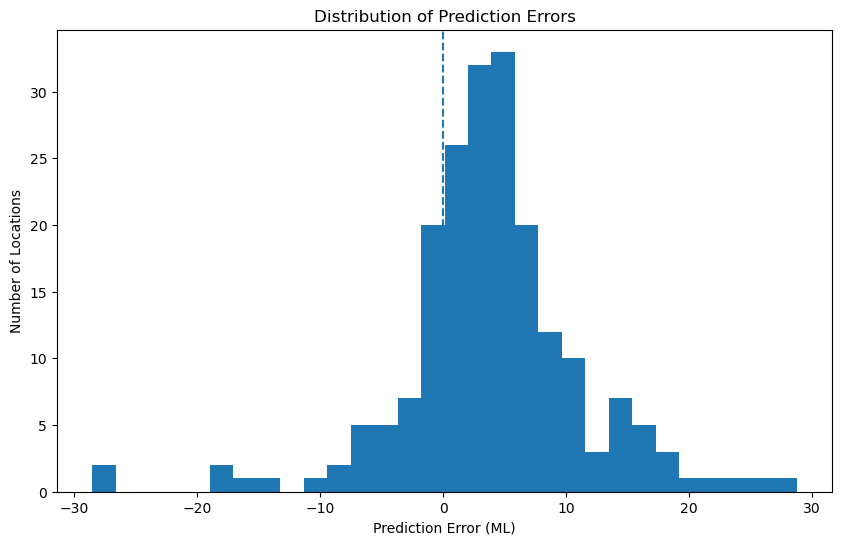

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_predictions["prediction_error_ml"],
    bins=30
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (ML)")
plt.ylabel("Number of Locations")
plt.title("Distribution of Prediction Errors")

plt.show()

# Actual vs Predicted Consumption

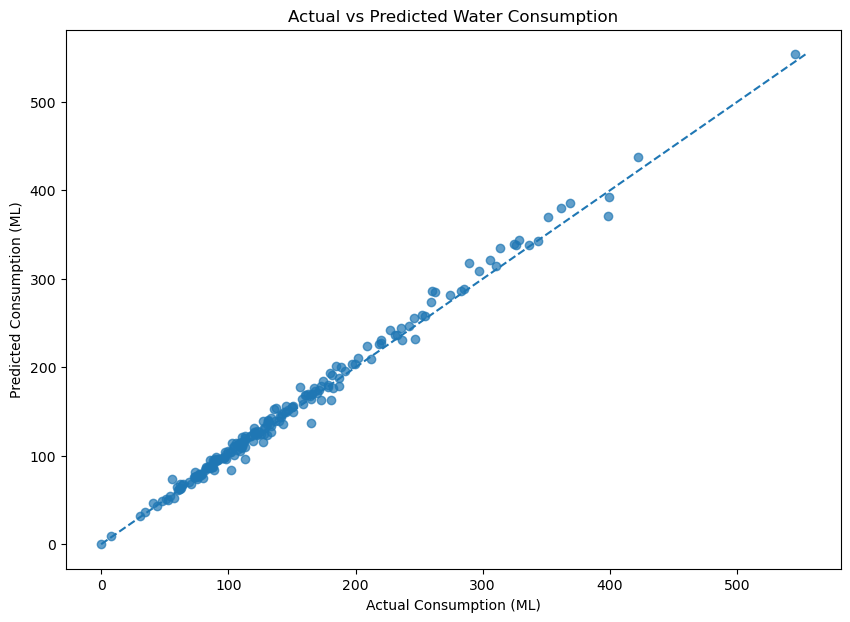

In [19]:
plt.figure(figsize=(10, 7))

plt.scatter(
    final_predictions["actual_consumption_ml"],
    final_predictions["predicted_consumption_ml"],
    alpha=0.7
)

min_value = min(
    final_predictions["actual_consumption_ml"].min(),
    final_predictions["predicted_consumption_ml"].min()
)

max_value = max(
    final_predictions["actual_consumption_ml"].max(),
    final_predictions["predicted_consumption_ml"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Consumption (ML)")
plt.ylabel("Predicted Consumption (ML)")
plt.title("Actual vs Predicted Water Consumption")

plt.show()

In [21]:
performance_summary.to_csv(
    "../Analysis/analysis_summary.csv",
    index=False
)

print("Saved: Analysis/analysis_summary.csv")

Saved: Analysis/analysis_summary.csv


# 6. Location-Level Error Analysis

This section identifies locations where the final model has the highest prediction errors.

The analysis uses:

- Actual consumption
- Predicted consumption
- Mean Absolute Error (MAE)
- Mean prediction error
- Mean absolute percentage error

# Location-Level Error Analysis


In [22]:
location_error = (
    final_predictions
    .groupby("location_id", as_index=False)
    .agg(
        actual_consumption_ml=("actual_consumption_ml", "mean"),
        predicted_consumption_ml=("predicted_consumption_ml", "mean"),
        mae_ml=("prediction_error_ml", lambda x: x.abs().mean()),
        mean_error_ml=("prediction_error_ml", "mean"),
        mean_error_pct=("prediction_error_pct", "mean")
    )
    .sort_values(
        "mae_ml",
        ascending=False
    )
)

print("Locations with highest prediction error:")
display(location_error.head(20))

Locations with highest prediction error:


,location_id,actual_consumption_ml,predicted_consumption_ml,mae_ml,mean_error_ml,mean_error_pct
66,159_kengeri,289.48,318.223348,28.743348,28.743348,9.929304
118,25_horamavu,165.27,136.739839,28.530161,-28.530161,-17.262758
108,196_anjanapura,398.77,371.098001,27.671999,-27.671999,-6.939338
120,27_banasawadi,260.34,285.844231,25.504231,25.504231,9.796509
84,175_bommanahalli,262.12,285.368719,23.248719,23.248719,8.869495
184,85_doddanekkundi,313.53,335.078022,21.548022,21.548022,6.872715
186,86_marathalli,156.37,177.273696,20.903696,20.903696,13.368099
195,94_gandhinagar,350.94,369.969185,19.029185,19.029185,5.422347
146,50_benniganahalli,361.26,379.568000,18.308000,18.308000,5.067818
185,85_varthur,102.27,84.161824,18.108176,-18.108176,-17.706245


In [24]:
location_error.to_csv(
    "../Analysis/location_error_analysis.csv",
    index=False
)

print("Saved: 04_Analysis/location_error_analysis.csv")

Saved: 04_Analysis/location_error_analysis.csv


# Largest Individual Prediction Errors


In [25]:
largest_errors = (
    final_predictions[
        [
            "location_id",
            "forecast_month",
            "actual_consumption_ml",
            "predicted_consumption_ml",
            "prediction_error_ml",
            "prediction_error_pct"
        ]
    ]
    .assign(
        absolute_error_ml=lambda df:
            df["prediction_error_ml"].abs()
    )
    .sort_values(
        "absolute_error_ml",
        ascending=False
    )
)

print("Top 20 largest prediction errors:")
display(largest_errors.head(20))

Top 20 largest prediction errors:


,location_id,forecast_month,actual_consumption_ml,predicted_consumption_ml,prediction_error_ml,prediction_error_pct,absolute_error_ml
66,159_kengeri,2026-03-01,289.48,318.223348,28.743348,9.929304,28.743348
118,25_horamavu,2026-03-01,165.27,136.739839,-28.530161,-17.262758,28.530161
108,196_anjanapura,2026-03-01,398.77,371.098001,-27.671999,-6.939338,27.671999
120,27_banasawadi,2026-03-01,260.34,285.844231,25.504231,9.796509,25.504231
84,175_bommanahalli,2026-03-01,262.12,285.368719,23.248719,8.869495,23.248719
184,85_doddanekkundi,2026-03-01,313.53,335.078022,21.548022,6.872715,21.548022
186,86_marathalli,2026-03-01,156.37,177.273696,20.903696,13.368099,20.903696
195,94_gandhinagar,2026-03-01,350.94,369.969185,19.029185,5.422347,19.029185
146,50_benniganahalli,2026-03-01,361.26,379.568000,18.308000,5.067818,18.308000
185,85_varthur,2026-03-01,102.27,84.161824,-18.108176,-17.706245,18.108176


In [26]:
largest_errors.to_csv(
    "../Analysis/prediction_error_analysis.csv",
    index=False
)

print("Saved: 04_Analysis/prediction_error_analysis.csv")

Saved: 04_Analysis/prediction_error_analysis.csv


In [27]:
print("Location analysis shape:", location_error.shape)
print("Largest error analysis shape:", largest_errors.shape)

print("\nTop 5 locations by MAE:")
display(location_error.head(5))

print("\nTop 5 individual errors:")
display(largest_errors.head(5))

Location analysis shape: (202, 6)
Largest error analysis shape: (202, 7)

Top 5 locations by MAE:


,location_id,actual_consumption_ml,predicted_consumption_ml,mae_ml,mean_error_ml,mean_error_pct
66,159_kengeri,289.48,318.223348,28.743348,28.743348,9.929304
118,25_horamavu,165.27,136.739839,28.530161,-28.530161,-17.262758
108,196_anjanapura,398.77,371.098001,27.671999,-27.671999,-6.939338
120,27_banasawadi,260.34,285.844231,25.504231,25.504231,9.796509
84,175_bommanahalli,262.12,285.368719,23.248719,23.248719,8.869495



Top 5 individual errors:


,location_id,forecast_month,actual_consumption_ml,predicted_consumption_ml,prediction_error_ml,prediction_error_pct,absolute_error_ml
66,159_kengeri,2026-03-01,289.48,318.223348,28.743348,9.929304,28.743348
118,25_horamavu,2026-03-01,165.27,136.739839,-28.530161,-17.262758,28.530161
108,196_anjanapura,2026-03-01,398.77,371.098001,-27.671999,-6.939338,27.671999
120,27_banasawadi,2026-03-01,260.34,285.844231,25.504231,9.796509,25.504231
84,175_bommanahalli,2026-03-01,262.12,285.368719,23.248719,8.869495,23.248719


# Risk / Anomaly Analysis


In [28]:
risk_analysis = final_predictions[
    [
        "forecast_month",
        "location_id",
        "actual_consumption_ml",
        "predicted_consumption_ml",
        "prediction_error_ml",
        "prediction_error_pct",
        "deviation_pct",
        "rolling_3_month_std",
        "consumption_change_pct"
    ]
].copy()

# Absolute prediction error percentage
risk_analysis["abs_prediction_error_pct"] = (
    risk_analysis["prediction_error_pct"].abs()
)

# Absolute deviation percentage
risk_analysis["abs_deviation_pct"] = (
    risk_analysis["deviation_pct"].abs()
)

# Absolute consumption change percentage
risk_analysis["abs_consumption_change_pct"] = (
    risk_analysis["consumption_change_pct"].abs()
)

# ---------------------------------------------------------
# Create risk indicators
# ---------------------------------------------------------

risk_analysis["high_prediction_error"] = (
    risk_analysis["abs_prediction_error_pct"] >= 10
).astype(int)

risk_analysis["high_deviation"] = (
    risk_analysis["abs_deviation_pct"] >= 10
).astype(int)

risk_analysis["high_variability"] = (
    risk_analysis["rolling_3_month_std"] >=
    risk_analysis["rolling_3_month_std"].quantile(0.75)
).astype(int)

risk_analysis["high_consumption_change"] = (
    risk_analysis["abs_consumption_change_pct"] >= 10
).astype(int)

# ---------------------------------------------------------
# Overall risk score
# ---------------------------------------------------------

risk_analysis["risk_score"] = (
    risk_analysis["high_prediction_error"]
    + risk_analysis["high_deviation"]
    + risk_analysis["high_variability"]
    + risk_analysis["high_consumption_change"]
)

# Risk category
risk_analysis["risk_category"] = np.select(
    [
        risk_analysis["risk_score"] >= 3,
        risk_analysis["risk_score"] == 2,
        risk_analysis["risk_score"] == 1
    ],
    [
        "High",
        "Medium",
        "Low"
    ],
    default="Normal"
)

# Sort highest risk first
risk_analysis = risk_analysis.sort_values(
    ["risk_score", "abs_prediction_error_pct"],
    ascending=[False, False]
)

print("Risk analysis shape:", risk_analysis.shape)

display(risk_analysis.head(20))

Risk analysis shape: (202, 18)


,forecast_month,location_id,actual_consumption_ml,predicted_consumption_ml,prediction_error_ml,prediction_error_pct,deviation_pct,rolling_3_month_std,consumption_change_pct,abs_prediction_error_pct,abs_deviation_pct,abs_consumption_change_pct,high_prediction_error,high_deviation,high_variability,high_consumption_change,risk_score,risk_category
185,2026-03-01,85_varthur,102.27,84.161824,-18.108176,-17.706245,29.433709,11.503714,37.533405,17.706245,29.433709,37.533405,1,1,1,1,4,High
123,2026-03-01,2_chowdeshwari_ward,56.01,74.025343,18.015343,32.164511,15.192039,8.605806,0.474705,32.164511,15.192039,0.474705,1,1,1,0,3,High
118,2026-03-01,25_horamavu,165.27,136.739839,-28.530161,-17.262758,21.363911,17.279227,7.204326,17.262758,21.363911,7.204326,1,1,1,0,3,High
126,2026-03-01,32_kavalbyrasandra,103.15,114.440347,11.290347,10.945562,12.428298,2.169977,10.029940,10.945562,12.428298,10.029940,1,1,0,1,3,High
192,2026-03-01,91_bharathinagar,112.97,96.731829,-16.238171,-14.373879,-4.282487,6.303388,2.374199,14.373879,4.282487,2.374199,1,0,1,0,2,Medium
15,2026-03-01,114_agaram,136.18,152.762297,16.582297,12.176749,7.250233,6.520153,5.028661,12.176749,7.250233,5.028661,1,0,1,0,2,Medium
95,2026-03-01,185_yelachenahalli,180.07,194.023364,13.953364,7.748855,10.343193,6.085929,6.303362,7.748855,10.343193,6.303362,0,1,1,0,2,Medium
108,2026-03-01,196_anjanapura,398.77,371.098001,-27.671999,-6.939338,16.127998,36.615201,3.638256,6.939338,16.127998,3.638256,0,1,1,0,2,Medium
110,2026-03-01,198_hemmigepura,142.71,135.497364,-7.212636,-5.054051,13.749149,8.498920,5.350386,5.054051,13.749149,5.350386,0,1,1,0,2,Medium
167,2026-03-01,6_thanisandra,88.40,83.952557,-4.447443,-5.031044,15.316932,6.206741,5.477477,5.031044,15.316932,5.477477,0,1,1,0,2,Medium


In [29]:
print("Risk category counts:")
display(
    risk_analysis["risk_category"]
    .value_counts()
    .rename_axis("risk_category")
    .reset_index(name="count")
)

Risk category counts:


,risk_category,count
0,Normal,141
1,Low,49
2,Medium,8
3,High,4


In [30]:
print("Top 20 highest-risk locations:")

display(
    risk_analysis[
        [
            "location_id",
            "forecast_month",
            "actual_consumption_ml",
            "predicted_consumption_ml",
            "abs_prediction_error_pct",
            "abs_deviation_pct",
            "rolling_3_month_std",
            "abs_consumption_change_pct",
            "risk_score",
            "risk_category"
        ]
    ].head(20)
)

Top 20 highest-risk locations:


,location_id,forecast_month,actual_consumption_ml,predicted_consumption_ml,abs_prediction_error_pct,abs_deviation_pct,rolling_3_month_std,abs_consumption_change_pct,risk_score,risk_category
185,85_varthur,2026-03-01,102.27,84.161824,17.706245,29.433709,11.503714,37.533405,4,High
123,2_chowdeshwari_ward,2026-03-01,56.01,74.025343,32.164511,15.192039,8.605806,0.474705,3,High
118,25_horamavu,2026-03-01,165.27,136.739839,17.262758,21.363911,17.279227,7.204326,3,High
126,32_kavalbyrasandra,2026-03-01,103.15,114.440347,10.945562,12.428298,2.169977,10.029940,3,High
192,91_bharathinagar,2026-03-01,112.97,96.731829,14.373879,4.282487,6.303388,2.374199,2,Medium
15,114_agaram,2026-03-01,136.18,152.762297,12.176749,7.250233,6.520153,5.028661,2,Medium
95,185_yelachenahalli,2026-03-01,180.07,194.023364,7.748855,10.343193,6.085929,6.303362,2,Medium
108,196_anjanapura,2026-03-01,398.77,371.098001,6.939338,16.127998,36.615201,3.638256,2,Medium
110,198_hemmigepura,2026-03-01,142.71,135.497364,5.054051,13.749149,8.498920,5.350386,2,Medium
167,6_thanisandra,2026-03-01,88.40,83.952557,5.031044,15.316932,6.206741,5.477477,2,Medium


In [31]:
risk_analysis.to_csv(
    "../Analysis/risk_analysis.csv",
    index=False
)

print("Saved: 04_Analysis/risk_analysis.csv")

Saved: 04_Analysis/risk_analysis.csv


# Visualization
 Actual Vs Predicted Consumption

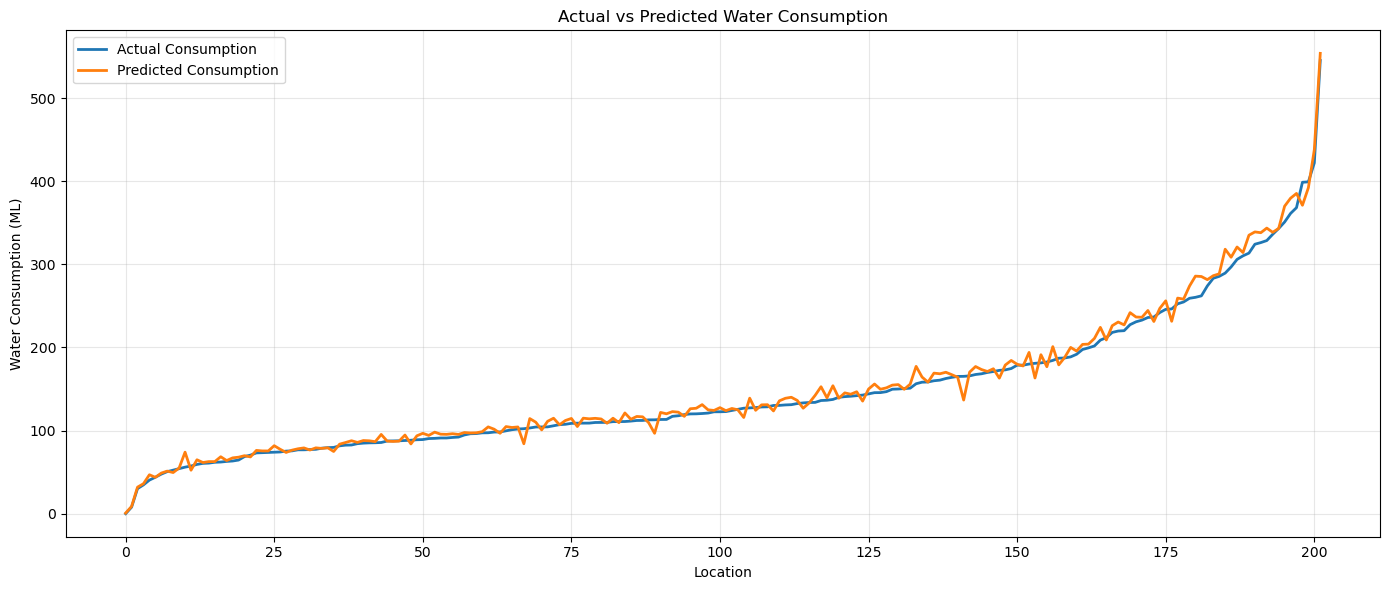

Saved: 05_Visualizations/actual_vs_predicted.png


In [34]:

import matplotlib.pyplot as plt
import numpy as np
import os

# Create visualization directory if it does not exist
os.makedirs("../Visualization", exist_ok=True)

# Sort by actual consumption for a cleaner visualization
plot_data = final_predictions[
    [
        "location_id",
        "actual_consumption_ml",
        "predicted_consumption_ml"
    ]
].sort_values(
    "actual_consumption_ml"
).reset_index(drop=True)

x = np.arange(len(plot_data))

plt.figure(figsize=(14, 6))

plt.plot(
    x,
    plot_data["actual_consumption_ml"],
    label="Actual Consumption",
    linewidth=2
)

plt.plot(
    x,
    plot_data["predicted_consumption_ml"],
    label="Predicted Consumption",
    linewidth=2
)

plt.xlabel("Location")
plt.ylabel("Water Consumption (ML)")
plt.title("Actual vs Predicted Water Consumption")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../visualization/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: 05_Visualizations/actual_vs_predicted.png")

Prediction Error Distribution

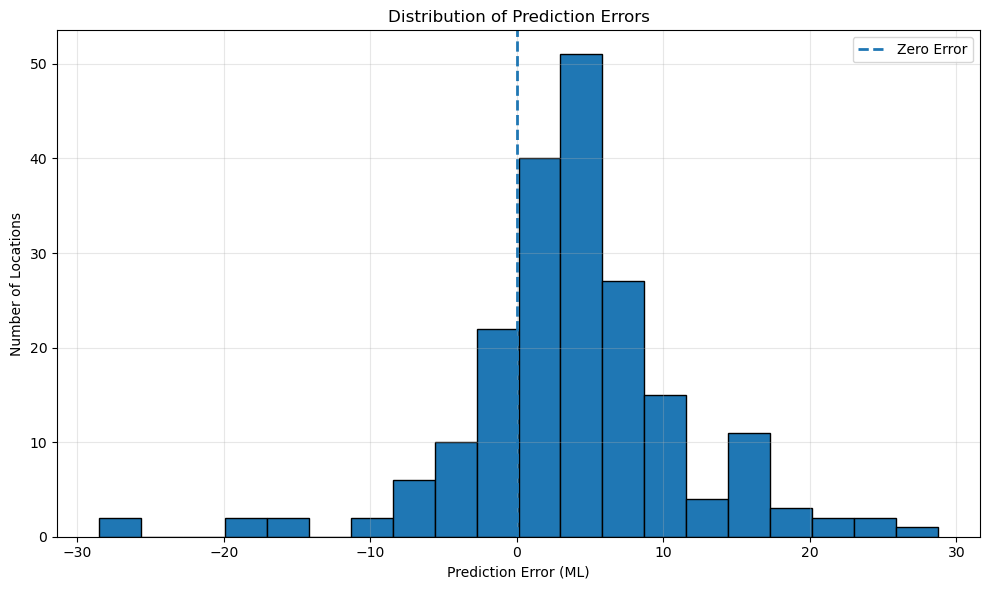

Saved: 05_Visualizations/prediction_error_distribution.png


In [36]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_predictions["prediction_error_ml"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)

plt.xlabel("Prediction Error (ML)")
plt.ylabel("Number of Locations")
plt.title("Distribution of Prediction Errors")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../visualization/prediction_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: 05_Visualizations/prediction_error_distribution.png")

Top Error Locations

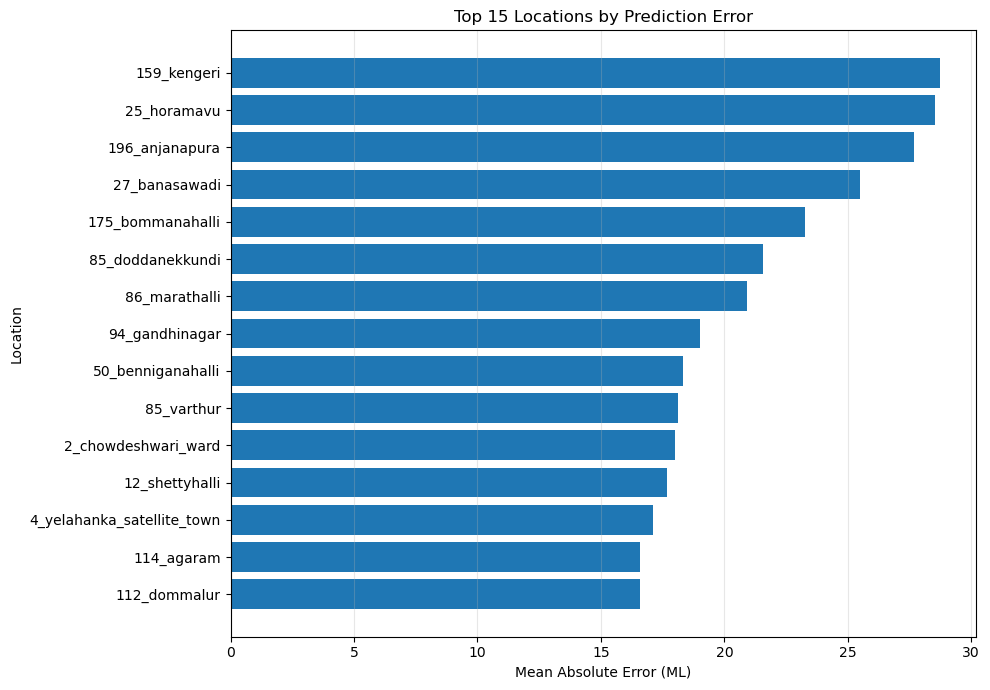

Saved: 05_Visualizations/top_error_locations.png


In [37]:
top_locations = (
    location_error
    .sort_values("mae_ml", ascending=False)
    .head(15)
    .sort_values("mae_ml")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_locations["location_id"],
    top_locations["mae_ml"]
)

plt.xlabel("Mean Absolute Error (ML)")
plt.ylabel("Location")
plt.title("Top 15 Locations by Prediction Error")

plt.grid(True, axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../visualization/top_error_locations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: 05_Visualizations/top_error_locations.png")

Consumption Risk

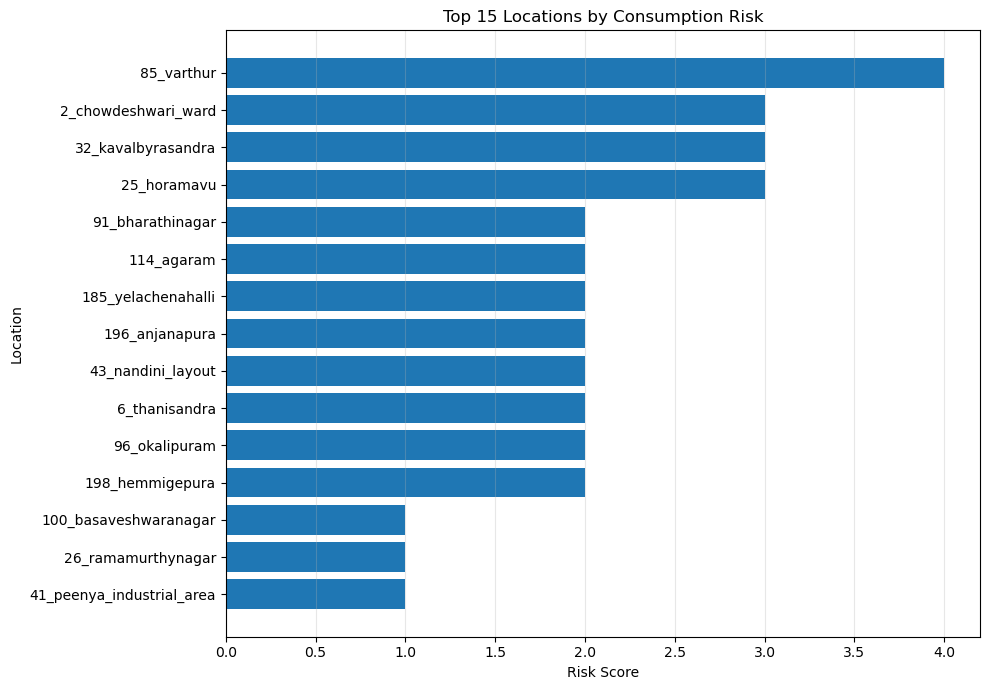

Saved: 05_Visualizations/consumption_risk.png


In [38]:
top_risk = (
    risk_analysis
    .sort_values("risk_score", ascending=False)
    .head(15)
    .sort_values("risk_score")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_risk["location_id"],
    top_risk["risk_score"]
)

plt.xlabel("Risk Score")
plt.ylabel("Location")
plt.title("Top 15 Locations by Consumption Risk")

plt.grid(True, axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../visualization/consumption_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: 05_Visualizations/consumption_risk.png")

Feature Importance

In [39]:
import joblib

rf_model = joblib.load(
    "../models/random_forest_model.pkl"
)

print("Random Forest model loaded successfully.")

Random Forest model loaded successfully.


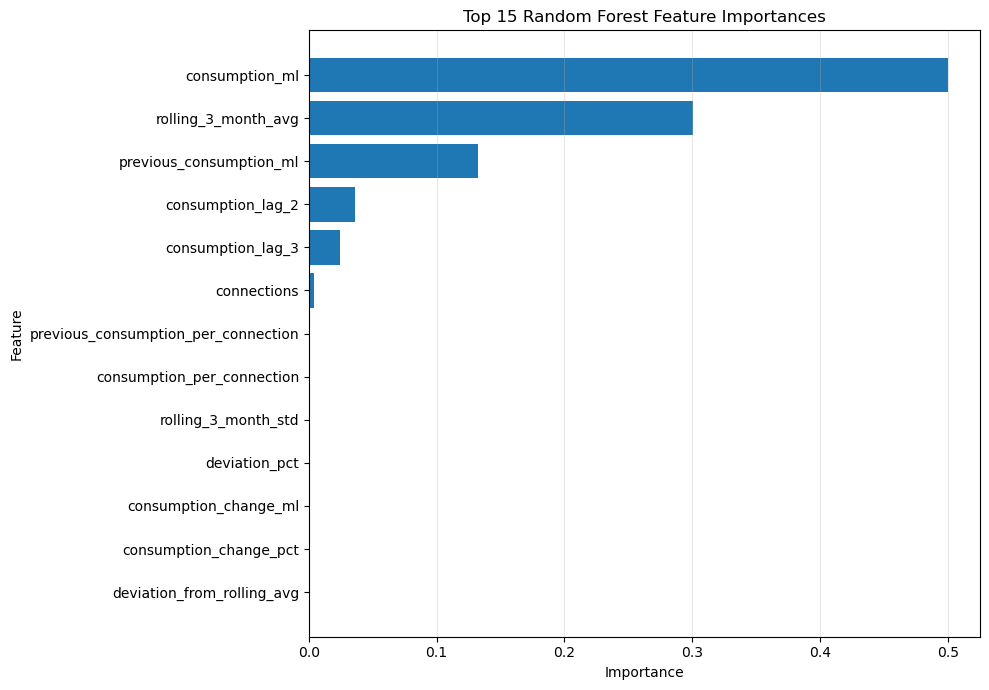

Saved: 05_Visualizations/feature_importance.png


In [40]:
feature_importance = pd.DataFrame({
    "feature": rf_model.feature_names_in_,
    "importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.grid(True, axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../visualization/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: 05_Visualizations/feature_importance.png")

In [42]:
import os

visualization_folder = "../visualization"

print("Visualization files:")

for file in sorted(os.listdir(visualization_folder)):
    print("-", file)

Visualization files:
- actual_vs_predicted.png
- consumption_risk.png
- feature_importance.png
- prediction_error_distribution.png
- top_error_locations.png


In [44]:
final_predictions = pd.read_csv(
    "../data/final/water_consumption_forecast_predictions.csv"
)

print("Final prediction dataset shape:", final_predictions.shape)

print("\nColumns:")
print(final_predictions.columns.tolist())

print("\nMissing values:")
print(final_predictions.isna().sum())

Final prediction dataset shape: (202, 15)

Columns:
['location_id', 'connections', 'forecast_month', 'actual_consumption_ml', 'predicted_consumption_ml', 'prediction_error_ml', 'absolute_error_ml', 'prediction_error_pct', 'rolling_3_month_avg', 'deviation_from_rolling_avg', 'deviation_pct', 'rolling_3_month_std', 'consumption_change_pct', 'consumption_lag_2', 'consumption_lag_3']

Missing values:
location_id                   0
connections                   0
forecast_month                0
actual_consumption_ml         0
predicted_consumption_ml      0
prediction_error_ml           0
absolute_error_ml             0
prediction_error_pct          1
rolling_3_month_avg           0
deviation_from_rolling_avg    0
deviation_pct                 0
rolling_3_month_std           0
consumption_change_pct        0
consumption_lag_2             0
consumption_lag_3             0
dtype: int64


In [46]:
print("FINAL PROJECT DATA CHECK")
print("=" * 40)

print("Final predictions:")
print(final_predictions.shape)

print("\nLocations:")
print(final_predictions["location_id"].nunique())

print("\nForecast months:")
print(final_predictions["forecast_month"].nunique())

print("\nForecast month:")
print(final_predictions["forecast_month"].unique())

print("\nAnalysis files:")
print(os.listdir("../Analysis"))

print("\nVisualization files:")
print(os.listdir("../visualization"))

FINAL PROJECT DATA CHECK
Final predictions:
(202, 15)

Locations:
202

Forecast months:
1

Forecast month:
['2026-03-01']

Analysis files:
['analysis_summary.csv', 'location_error_analysis.csv', 'prediction_error_analysis.csv', 'risk_analysis.csv']

Visualization files:
['actual_vs_predicted.png', 'consumption_risk.png', 'feature_importance.png', 'prediction_error_distribution.png', 'top_error_locations.png']
